#**Project Title: Financial Service Excellence & Customer Experience (CX) Analytics**

**Target Stakeholder:** Human Resources & Talent Management

**Author:** Cantwel Njeri

**Tools Used:** MySQL, Python (Pandas/SQLAlchemy), Power BI

**Project Overview**

This project explores the intersection of Customer Experience (CX) and Human Capital Management. In the financial services sector, customer satisfaction is a primary KPI for measuring employee performance, training effectiveness, and operational service delivery.

The goal of this end-to-end pipeline is to transform raw customer interaction data into actionable insights that help HR departments optimize staff training and regional performance.

**Problem Statement**

Modern banks struggle to bridge the gap between "Customer Feedback" and "Employee Development." Without a clear link between these two data points, HR cannot effectively:

* Pinpoint regional service friction.

* Correlate customer sentiment with retention risks.

* Identify high-value service interactions that should be modeled in staff training programs.

**Objective:** Build a scalable data pipeline to extract, process, and visualize customer service metrics to drive data-informed talent decisions.

#**1. Environment Setup & Data Ingestion**
The first phase of the project involves preparing the development environment and establishing a connection to the data source. To ensure reproducibility and scalability, the project utilizes a relational database management system (RDBMS) for storage and a Python-based ETL (Extract, Transform, Load) pipeline.

**Technical Stack:**

**Data Manipulation:** Pandas and NumPy for efficient table operations and numerical calculations.

**Database Connectivity:** SQLAlchemy to bridge the gap between Python data structures and the SQL relational schema.

**Data Visualization:** Matplotlib and Seaborn for Exploratory Data Analysis (EDA) and trend identification before moving to Power BI.

**Database:** SQLite 3 (A serverless, file-based relational database ideal for portable data science workflows).

**Source:** Initial raw dataset provided in CSV format (customer_experience_data.csv).

**Ingestion Strategy:**
The data is initially read into a Python environment to verify structure before being staged for database migration. This approach allows for pre-processing checks to ensure the database schema remains optimized for analytical queries.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load the data into a variable called 'df' (short for DataFrame)
df = pd.read_csv('/content/customer_experience_data.csv')

#**2. Data Cleaning & Preliminary Audit**

Before performing any transformations, a thorough audit of the raw dataset was conducted to ensure data integrity.

In [ ]:
# See the first 5 rows to understand the structure
df.head()

,Customer_ID,Age,Gender,Location,Num_Interactions,Feedback_Score,Products_Purchased,Products_Viewed,Time_Spent_on_Site,Satisfaction_Score,Retention_Status,Gender_Encoded,Location_Encoded,Retention_Status_Encoded
0,1,56,Male,Urban,11,4,18,38,18.319606,7,Retained,1,2,1
1,2,69,Male,Suburban,10,3,2,17,9.015198,6,Retained,1,1,1
2,3,46,Male,Urban,5,5,11,46,45.921572,10,Churned,1,2,0
3,4,32,Female,Suburban,5,1,6,13,44.105053,5,Churned,0,1,0
4,5,60,Male,Urban,14,5,8,46,17.897471,1,Retained,1,2,1


In [ ]:
# Check for missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               1000 non-null   int64  
 1   Age                       1000 non-null   int64  
 2   Gender                    1000 non-null   object 
 3   Location                  1000 non-null   object 
 4   Num_Interactions          1000 non-null   int64  
 5   Feedback_Score            1000 non-null   int64  
 6   Products_Purchased        1000 non-null   int64  
 7   Products_Viewed           1000 non-null   int64  
 8   Time_Spent_on_Site        1000 non-null   float64
 9   Satisfaction_Score        1000 non-null   int64  
 10  Retention_Status          1000 non-null   object 
 11  Gender_Encoded            1000 non-null   int64  
 12  Location_Encoded          1000 non-null   int64  
 13  Retention_Status_Encoded  1000 non-null   int64  
dtypes: float6

In [ ]:
# Get to know the number of rows and column in the dataset
df.shape

(1000, 14)

In [ ]:
# Get a quick summary of the numbers (Min, Max, Average)
df.describe()

,Customer_ID,Age,Num_Interactions,Feedback_Score,Products_Purchased,Products_Viewed,Time_Spent_on_Site,Satisfaction_Score,Gender_Encoded,Location_Encoded,Retention_Status_Encoded
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,500.500000,43.81900,7.545000,2.985000,10.417000,27.370000,32.274399,5.540000,0.524000,1.032000,0.69400
std,288.819436,14.99103,4.016978,1.418022,5.345623,12.939572,15.734978,2.904279,0.499674,0.809711,0.46106
min,1.000000,18.00000,1.000000,1.000000,1.000000,5.000000,5.114208,1.000000,0.000000,0.000000,0.00000
25%,250.750000,31.00000,4.000000,2.000000,6.000000,17.000000,18.836771,3.000000,0.000000,0.000000,0.00000
50%,500.500000,44.00000,8.000000,3.000000,11.000000,27.500000,32.455598,6.000000,1.000000,1.000000,1.00000
75%,750.250000,56.00000,11.000000,4.000000,15.000000,38.000000,45.932524,8.000000,1.000000,2.000000,1.00000
max,1000.000000,69.00000,14.000000,5.000000,19.000000,49.000000,59.947722,10.000000,1.000000,2.000000,1.00000


In [ ]:
# Verify missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Customer_ID                 0
Age                         0
Gender                      0
Location                    0
Num_Interactions            0
Feedback_Score              0
Products_Purchased          0
Products_Viewed             0
Time_Spent_on_Site          0
Satisfaction_Score          0
Retention_Status            0
Gender_Encoded              0
Location_Encoded            0
Retention_Status_Encoded    0
dtype: int64


In [ ]:
#  Check for duplicate rows
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")


Number of duplicate rows: 0


In [ ]:
# Select only the columns that matter for the CX report
# We are removing the '_Encoded' columns to keep the data professional
clean_df = df[[
    'Customer_ID', 'Age', 'Gender', 'Location',
    'Num_Interactions', 'Feedback_Score', 'Products_Purchased',
    'Products_Viewed', 'Time_Spent_on_Site', 'Satisfaction_Score',
    'Retention_Status'
]].copy()

print("\nData subset created. New shape:", clean_df.shape)


Data subset created. New shape: (1000, 11)


In [ ]:
#The outlier check
# Check the range of the data to ensure no impossible values
print(clean_df[['Age', 'Feedback_Score', 'Satisfaction_Score']].describe())

              Age  Feedback_Score  Satisfaction_Score
count  1000.00000     1000.000000         1000.000000
mean     43.81900        2.985000            5.540000
std      14.99103        1.418022            2.904279
min      18.00000        1.000000            1.000000
25%      31.00000        2.000000            3.000000
50%      44.00000        3.000000            6.000000
75%      56.00000        4.000000            8.000000
max      69.00000        5.000000           10.000000


While the dataset was found to be structurally sound with no missing values, several "cleaning" steps were taken to prepare it for a professional HR-facing dashboard.

**Audit Checklist:**
* **Null Value Check:** Verified that all 1,000 records contain complete information.

* **Duplicate Verification:** Confirmed that no redundant customer entries exist.

* **Data Consistency:** Standardized categorical strings (Location and Gender) for uniform visualization.

* **Schema Refinement:** Removed machine-learning specific columns (e.g., _Encoded) to prioritize human-readable fields for stakeholder reporting.

* **Logical Validation:** Ensured all numerical ranges (Age, Satisfaction Scores) fall within realistic business parameters.

#**3. Database Migration & Storage (SQLite)**

The final stage of the ETL (Extract, Transform, Load) process is migrating the enriched dataset into a relational database. For this project, SQLite was chosen as the RDBMS to ensure a portable, serverless, and reproducible workflow within the Google Colab environment.

**The Strategy:**

**Database Engine:** We use SQLAlchemy’s create_engine to initialize a local .db file. This allows for a "zero-configuration" setup where the database lives directly within the project directory.

**Loading Method:** The to_sql function in Pandas is utilized to automatically map the DataFrame schema to SQL tables and insert all 1,000 records in a single transactional block.

**Portability:** By using SQLite, the final database can be downloaded as a single file and instantly connected to Power BI or Tableau without requiring external server credentials.

In [ ]:
# Create the SQLite engine (the '///' indicates a local file)
engine = create_engine('sqlite:///bank_analytics.db')

In [ ]:
# Connect to our SQLite database
conn = sqlite3.connect('bank_analytics.db')

In [ ]:
# Push the dataframe to SQL (This creates the table 'customer_service_data')
clean_df.to_sql('customer_service_data', con=engine, if_exists='replace', index=False)

print("✅ Table 'customer_service_data' has been created successfully!")

✅ Table 'customer_service_data' has been created successfully!


#**4. Exploratory Data Analysis**

In [ ]:
# SQL Query: Categorize Feedback and Count totals
sentiment_query = """
SELECT
    CASE
        WHEN Feedback_Score >= 4 THEN 'Positive'
        WHEN Feedback_Score = 3 THEN 'Neutral'
        ELSE 'Negative'
    END AS Sentiment_Group,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(Products_Purchased), 2) AS Avg_Items_Bought
FROM customer_service_data
GROUP BY Sentiment_Group
ORDER BY Total_Customers DESC;
"""

In [ ]:
# Execute and Display
sentiment_results = pd.read_sql_query(sentiment_query, conn)
print("📊 EXECUTIVE SENTIMENT SUMMARY")
print(sentiment_results)

📊 EXECUTIVE SENTIMENT SUMMARY
  Sentiment_Group  Total_Customers  Avg_Items_Bought
0        Positive              394             10.29
1        Negative              394             10.46
2         Neutral              212             10.56


**The Sentiment Split:** Our customer base is split perfectly between "Positive" and "Negative" advocates (394 each). This indicates a highly polarized service environment where half the population is at risk of churn.

**The "Value at Risk" Paradox:** Interestingly, Negative customers buy more on average (10.46 items) than Positive customers (10.29 items). This suggests that our highest-volume users are currently experiencing the most friction.

**Critical Warning:** We cannot equate high purchasing volume with high satisfaction. Our most "valuable" customers in terms of quantity are currently our most dissatisfied, representing a significant Revenue Risk.

In [ ]:
# SQL Query: Understand the distribution of customers
distribution_query = """
SELECT
    Location,
    COUNT(*) AS Total_Customers,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM customer_service_data), 2) AS Percentage_of_Base,
    ROUND(AVG(Feedback_Score), 2) AS Overall_Avg_Score
FROM customer_service_data
GROUP BY Location
ORDER BY Total_Customers DESC;
"""
dist_results = pd.read_sql_query(distribution_query, conn)

print("🌍 MARKET SHARE: WHERE ARE OUR CUSTOMERS?")
print(dist_results)

🌍 MARKET SHARE: WHERE ARE OUR CUSTOMERS?
   Location  Total_Customers  Percentage_of_Base  Overall_Avg_Score
0     Urban              344                34.4               2.92
1  Suburban              344                34.4               3.01
2     Rural              312                31.2               3.03


**📍 Market Segmentation & Service Equity Audit**

To provide a baseline for our ETL pipeline, we first analyze the geographic distribution of the customer base. This ensures that our subsequent service quality audits are grounded in a clear understanding of our market footprint.

**Key Strategic Observations:**

* **Balanced Market Presence:** The dataset reveals a remarkably uniform distribution. Our customer base is split almost equally across all three sectors, indicating that our brand has achieved consistent penetration in Urban, Suburban, and Rural markets.

* **Performance Baseline:** The Rural and Suburban sectors are currently performing above the 3.00 average, suggesting a stable service environment.

* **The Urban Opportunity:** Although the Urban sector has the exact same customer volume as the Suburban sector (344), it shows a slightly lower average satisfaction score (2.92). This identifies the Urban market as the primary area for further investigation into service efficiency.

In [ ]:
# SQL Query: Calculate the % of the population that is unhappy per location
risk_assessment_query = """
SELECT
    Location,
    COUNT(*) AS Negative_Count,
    (SELECT COUNT(*) FROM customer_service_data t2 WHERE t2.Location = t1.Location) AS Total_Location_Pop,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM customer_service_data t2 WHERE t2.Location = t1.Location), 2) AS Dissatisfaction_Rate_Pct,
    ROUND(AVG(Feedback_Score), 2) AS Avg_Negative_Score
FROM customer_service_data t1
WHERE Feedback_Score <= 2
GROUP BY Location
ORDER BY Dissatisfaction_Rate_Pct DESC;
"""
risk_results = pd.read_sql_query(risk_assessment_query, conn)

print("🚨 GEOGRAPHIC RISK ASSESSMENT: DISSATISFACTION BY REGION")
print(risk_results)

🚨 GEOGRAPHIC RISK ASSESSMENT: DISSATISFACTION BY REGION
   Location  Negative_Count  Total_Location_Pop  Dissatisfaction_Rate_Pct  \
0     Urban             146                 344                     42.44   
1     Rural             119                 312                     38.14   
2  Suburban             129                 344                     37.50   

   Avg_Negative_Score  
0                1.55  
1                1.48  
2                1.35  


**Key Strategic Observations:**

**Urban Criticality:** The Urban sector is our most volatile region, with over 42% of its customers reporting negative experiences. Even though it has the same population as the Suburban sector, its failure rate is nearly 5% higher, suggesting that higher customer density in Urban centers is straining our service capacity.

**The "Quiet" Crisis in Suburban:** While the Suburban sector has the lowest rate of dissatisfaction (37.50%), it has the lowest average score (1.35) among unhappy customers. This indicates that while fewer people are complaining in the suburbs, the complaints they do have are significantly more severe.

**Strategic Priority:** Resource allocation for service improvement should be prioritized for Urban centers to reduce the high volume of churn risk, while Suburban centers require a deep-dive audit into the root causes of their extremely low satisfaction scores.

In [ ]:
# Purpose: Identify high-value customers who are likely to leave the bank (Churn).
# Logic: We define 'High Churn Risk' as customers who have a large footprint (10+ products)
# but are deeply dissatisfied (Feedback Score <= 2).
churn_query = """
SELECT
    Customer_ID,
    Location,
    Products_Purchased,
    Feedback_Score,
    CASE
        WHEN Feedback_Score <= 2 AND Products_Purchased > 10 THEN 'High Churn Risk'
        WHEN Feedback_Score <= 2 AND Products_Purchased <= 10 THEN 'Medium Churn Risk'
        ELSE 'Stable'
    END AS Risk_Category
FROM customer_service_data
WHERE Risk_Category != 'Stable'
ORDER BY Products_Purchased DESC
LIMIT 10;
"""
churn_results = pd.read_sql_query(churn_query, conn)

print("🚨 CUSTOMER CHURN WATCHLIST (TOP 10)")
print(churn_results)

🚨 CUSTOMER CHURN WATCHLIST (TOP 10)
   Customer_ID  Location  Products_Purchased  Feedback_Score    Risk_Category
0           93     Urban                  19               2  High Churn Risk
1          150     Rural                  19               2  High Churn Risk
2          152  Suburban                  19               1  High Churn Risk
3          167  Suburban                  19               2  High Churn Risk
4          411     Urban                  19               1  High Churn Risk
5          565     Urban                  19               2  High Churn Risk
6          592  Suburban                  19               1  High Churn Risk
7          609  Suburban                  19               1  High Churn Risk
8          619     Rural                  19               1  High Churn Risk
9          634  Suburban                  19               1  High Churn Risk


**📍 High-Value Churn Watchlist: The "Top 10" Priority**

While aggregate data tells us where the problems are, this granular analysis tells us exactly who we are about to lose. These 10 customers represent our highest "Revenue at Risk."

**Critical Strategic Insights:**

**Maximum Exposure:** Every single customer on this list owns 19 products. These are "Power Users" who are deeply integrated into our banking ecosystem, making their dissatisfaction a critical operational failure.

**The Suburban Cluster:** Interestingly, 5 out of the Top 10 high-risk customers are from the Suburban sector. This reinforces our earlier finding: while Suburban has fewer complaints overall, the complaints they do have come from our most valuable, high-volume clients.

**Urgency Level:** These customers have already reached the "Breaking Point" (Scores of 1 or 2). Without immediate intervention—such as a direct reach-out from a Relationship Manager or a targeted loyalty incentive—churn is statistically imminent.

In [ ]:
# SQL Query: High Views but Low Purchases (Frustrated Browsers)

frustration_query = """
SELECT
    Customer_ID,
    Location,
    Products_Viewed,
    Products_Purchased,
    ROUND(CAST(Products_Purchased AS FLOAT) / Products_Viewed, 2) AS Calc_Conversion_Rate,
        Feedback_Score
FROM customer_service_data
WHERE Products_Viewed > 15 AND Products_Purchased < 5
ORDER BY Products_Viewed DESC
LIMIT 10;
"""
print(pd.read_sql_query(frustration_query, conn))

   Customer_ID  Location  Products_Viewed  Products_Purchased  \
0          318     Urban               49                   4   
1          570     Rural               49                   1   
2          588     Rural               49                   1   
3          664     Rural               49                   3   
4          873     Rural               49                   1   
5          648     Rural               48                   4   
6          794  Suburban               48                   3   
7          819  Suburban               48                   2   
8          185     Urban               47                   3   
9          304     Rural               47                   3   

   Calc_Conversion_Rate  Feedback_Score  
0                  0.08               3  
1                  0.02               2  
2                  0.02               5  
3                  0.06               4  
4                  0.02               1  
5                  0.08         

**📍 Digital Sales Friction: The "Browsing vs. Buying" Gap**

To identify operational bottlenecks, we analyzed "High-Intent" customers—those who have engaged deeply with our digital catalog (45+ views) but have failed to complete significant transactions.

**Key Strategic Observations:**

**The Efficiency Crisis:** We have identified multiple customers with conversion rates as low as 2%. This is significantly below the healthy industry average and indicates a major friction point in the "Add to Cart" or "Checkout" phase of our digital platform.

**The "Satisfied but Stuck" Persona:** Customer #588 has a perfect satisfaction score of 5, yet only purchased 1 out of 49 viewed items. This confirms that the barrier to revenue is operational, not emotional. The customer wants to buy, but the system is making it difficult.

**Geographic Trend:** A high concentration of these "Frustrated Browsers" is located in Rural areas. This may suggest that our digital platform is not optimized for lower-bandwidth connections or that delivery/branch fulfillment in rural sectors is a deterrent.

In [ ]:
# ---AGE GROUP SEGMENTATION ---

age_query = """
SELECT
    CASE
        WHEN Age < 30 THEN 'Under 30 (Young Adult)'
        WHEN Age BETWEEN 30 AND 50 THEN '30-50 (Established)'
        ELSE '51+ (Senior)'
    END AS Age_Group,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(Feedback_Score), 2) AS Avg_Satisfaction,
    ROUND(AVG(Products_Purchased), 2) AS Avg_Items_Bought
FROM customer_service_data
GROUP BY Age_Group
ORDER BY Age_Group;
"""
age_results = pd.read_sql_query(age_query, conn)

print("AGE GROUP ANALYSIS: LIFE-STAGE INSIGHTS")
print(age_results)

AGE GROUP ANALYSIS: LIFE-STAGE INSIGHTS
                Age_Group  Total_Customers  Avg_Satisfaction  Avg_Items_Bought
0     30-50 (Established)              415              3.07             10.33
1            51+ (Senior)              363              2.90             10.59
2  Under 30 (Young Adult)              222              2.97             10.28


**📍 Age Demographics: Life-Stage Value vs. Satisfaction**

By segmenting our customers into life stages, we can see which age groups drive the bank's volume and where our service model may be failing to meet specific demographic needs.

**Key Strategic Observations:**

**The "Established" Backbone:** The 30–50 age group is our largest and most stable segment. With the highest satisfaction score (3.07), this group likely represents our most reliable revenue stream.

**The Senior "Service Friction":** Customers aged 51+ buy the most products (10.59) but have the lowest satisfaction score (2.90). This is a critical insight—our most "invested" customers are the ones most likely to be frustrated, potentially by digital-first transitions or complex legacy processes.

**The Youth Retention Opportunity:** The Under-30 group is our smallest segment but maintains a relatively neutral score. There is significant room to grow this segment by addressing the "Frustrated Browsing" (low conversion) we identified earlier.

In [ ]:
# --- GENDER-BASED PERFORMANCE ---

gender_query = """
SELECT
    Gender,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(Feedback_Score), 2) AS Avg_Satisfaction,
    ROUND(AVG(Products_Purchased), 2) AS Avg_Products_Owned
FROM customer_service_data
GROUP BY Gender;
"""
gender_results = pd.read_sql_query(gender_query, conn)

print("👥 GENDER ANALYSIS: SATISFACTION vs. VALUE")
print(gender_results)

👥 GENDER ANALYSIS: SATISFACTION vs. VALUE
   Gender  Total_Customers  Avg_Satisfaction  Avg_Products_Owned
0  Female              476              2.99               10.59
1    Male              524              2.98               10.26


**📍 Gender Analysis: Service Equity & Portfolio Depth**
To ensure our service model is equitable, we analyzed performance metrics split by gender. The data reveals a highly balanced ecosystem with no significant "Service Gap" between groups.

**Key Strategic Observations:**

**Service Equity:** With a negligible difference of only $0.01$ in satisfaction scores, the bank's operational model is performing consistently across both demographics. This indicates that the "Urban Friction" we found earlier affects all genders equally.

**The "Portfolio Depth" Leader:** While there are more male customers in the database ($524$), female customers tend to hold a higher number of products on average ($10.59$). This suggests that female clients are more deeply integrated into the bank's ecosystem.

**Balanced Churn Risk:** Since the satisfaction scores are nearly identical, churn prevention strategies do not need to be gender-specific; they should instead focus on the Location (Urban) and Age (Senior) factors identified in previous sections.

In [ ]:
# --- THE MASTER RISK MATRIX ---
# Purpose: Intersecting Geography, Age, and Gender to find the 'at-risk' persona.
# Filtering for groups with > 10 members to ensure the average is meaningful.

master_risk_query = """
SELECT
    Location,
    Gender,
    CASE
        WHEN Age < 30 THEN 'Young Adult'
        WHEN Age BETWEEN 30 AND 50 THEN 'Established'
        ELSE 'Senior'
    END AS Age_Group,
    COUNT(*) AS Segment_Size,
    ROUND(AVG(Feedback_Score), 2) AS Avg_Satisfaction,
    ROUND(AVG(Products_Purchased), 2) AS Avg_Engagement
FROM customer_service_data
GROUP BY Location, Gender, Age_Group
HAVING Segment_Size > 10
ORDER BY Avg_Satisfaction ASC
LIMIT 5;
"""
master_results = pd.read_sql_query(master_risk_query, conn)

print("🎯 THE MASTER RISK MATRIX: TOP 5 TARGET SEGMENTS")
print(master_results)

🎯 THE MASTER RISK MATRIX: TOP 5 TARGET SEGMENTS
   Location  Gender    Age_Group  Segment_Size  Avg_Satisfaction  \
0     Urban  Female       Senior            61              2.51   
1     Rural    Male  Young Adult            32              2.59   
2     Urban    Male       Senior            63              2.78   
3  Suburban    Male  Established            77              2.82   
4     Urban    Male  Young Adult            34              2.85   

   Avg_Engagement  
0           10.43  
1            8.47  
2           10.89  
3           10.47  
4            8.94  


**📍 The Master Risk Matrix:** **Identifying the "High-Priority" Personas**

To provide a surgical approach to customer retention, we intersected Geography, Gender, and Life-Stage. This multidimensional view exposes the specific demographics where our service model is currently failing.

**Key Strategic Conclusions:**

**The "Urban Senior" Crisis:** Two of the top three most dissatisfied groups are Seniors in Urban areas. This confirms a systemic failure in how our urban branches or digital platforms serve older, high-value clients.

**High-Value Exposure:** The Urban Male Senior group has the highest engagement on this list (10.89 products) but a low score of 2.78. This is a massive "Revenue at Risk" segment.

**The Rural Youth Gap:** Interestingly, Rural Male Young Adults represent a unique pocket of dissatisfaction (2.59). Unlike the seniors, they have lower engagement (8.47), suggesting they may be "quietly churning" before fully committing to the bank's ecosystem.

# **5. Predictive Modeling (Churn Forecasting)**

Now that we have analyzed the historical trends, we will build a Machine Learning Model.

**The Objective**

The goal is to use the bank's historical "Answer Key" (retention_status_encoded) to train a student (the model) to recognize patterns. Once trained, this model can look at any customer and predict if they are likely to leave ($1$) or stay ($0$).

**The "Student's Study Guide" (Our Features)**

To help the model learn, we are providing it with the following numerical inputs:
1. **Age:** Does life stage impact loyalty?
2. **Products_Purchased:** Does a deeper relationship mean they stay longer?
3. **Products_Viewed:** Does "window shopping" without buying signal frustration?
4. **Gender_Encoded:** Are there gender-specific retention patterns?
5. **Location_Encoded:** Does the region (Urban/Rural) impact the likelihood of leaving?

**The Methodology: Logistic Regression**

We are using Logistic Regression, a foundational Data Science algorithm used for "Binary Classification" (Yes/No outcomes).

* **Training Set (80%):** We show the model 800 examples with the answers so it can learn.

* **Testing Set (20%):** We give the model 200 "hidden" examples to test its accuracy.

**What to look for in the results:**

* **Accuracy:** The percentage of times the model guessed correctly.
* **Precision:** How reliable the model is when it says someone will churn.
* **Feature Weights:** Which factors are the "Smoking Guns" that predict a customer is leaving?

In [ ]:
# Print columns just to be 100% sure of the spelling
print("📋 Columns found in your data:", df.columns.tolist())

📋 Columns found in your data: ['Customer_ID', 'Age', 'Gender', 'Location', 'Num_Interactions', 'Feedback_Score', 'Products_Purchased', 'Products_Viewed', 'Time_Spent_on_Site', 'Satisfaction_Score', 'Retention_Status', 'Gender_Encoded', 'Location_Encoded', 'Retention_Status_Encoded']


In [ ]:
# Define features and target
features = ['Age', 'Products_Purchased', 'Products_Viewed', 'Gender_Encoded', 'Location_Encoded']
target = 'Retention_Status_Encoded'

X = df[features]
y = df[target]

In [ ]:
# Split: 80% to learn, 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train the Model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Output the results
accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%")

🎯 Model Accuracy: 69.00%


In [ ]:
# The "Why": Feature Importance
importance = pd.DataFrame({'Feature': features, 'Weight': model.coef_[0]})
print("\n📊 THE CHURN WEIGHTS (Positive = Churn Risk, Negative = Loyalty)")
print(importance.sort_values(by='Weight', ascending=False))


📊 THE CHURN WEIGHTS (Positive = Churn Risk, Negative = Loyalty)
              Feature    Weight
3      Gender_Encoded  0.116399
0                 Age  0.004884
1  Products_Purchased -0.001499
2     Products_Viewed -0.005612
4    Location_Encoded -0.199031


**Predictive Modeling: The "Early Warning System"**

We transitioned from historical reporting to Supervised Machine Learning. Using a Logistic Regression algorithm, we trained a model to identify the statistical "fingerprint" of a customer likely to churn ($1$) versus one likely to stay ($0$).

**A. Model Performance**

* **Accuracy Score:** 69.00%
* **Strategic Value:** A 69% accuracy rate allows the bank to move from Reactive (asking why people left) to Proactive (intervening before they go). This is significantly more effective than random guessing, providing a data-driven foundation for retention campaigns.

**B. The "Tug-of-War":** Comprehensive Weight AnalysisThe model assigns a Weight (Coefficient) to each feature, representing its "pull" on a customer's decision.



### 🔍 Feature Importance: Deciphering the Churn Model

The table below breaks down the weights from our Logistic Regression model. These values explain how each feature influences the probability of a customer leaving the bank (Churn = 1).

| Feature | Weight | Impact Type | Strategic Insight |
| :--- | :---: | :---: | :--- |
| **Gender_Encoded** | `+0.1164` | **Churn Driver** | Since $1 = Male$, men are the primary churn risk. This aligns with our EDA showing they have lower satisfaction and fewer products. |
| **Age** | `+0.0049` | **Neutral** | Age has a negligible impact on churn. This suggests that "Life Stage" is less important than "Account Behavior." |
| **Products_Purchased** | `-0.0015` | **Weak Anchor** | A higher product count slightly increases loyalty, but it is currently a weak defense against churn. |
| **Products_Viewed** | `-0.0056` | **Weak Anchor** | High browsing activity correlates slightly with staying, suggesting "window shopping" is a sign of engagement, not necessarily frustration. |
| **Location_Encoded** | `-0.1990` | **Strongest Anchor** | **The Urban Effect:** As we move toward Urban centers ($2$), the probability of churn drops significantly. |

> **Note:** A **positive weight** increases the likelihood of Churn (1). A **negative weight** increases the likelihood of Retention (0).

**Key Takeaways for Management**

* **The Gender Gap:** We need to investigate why Male customers feel less "tethered" to the bank. Since they hold fewer products on average, cross-selling campaigns targeted at men could increase their "switching costs" and lower churn.

* **The Urban Paradox:** Urban customers are our most stable segment despite reporting lower satisfaction. This suggests high barriers to exit in cities. We must improve their experience now before a competitor reduces those barriers.

* **Behavior Over Demographics:** The fact that Age has almost zero weight compared to Location and Gender proves that where a customer is and how they interact with us matters more than how old they are.

/tmp/ipykernel_403/3496301947.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Feature', data=importance_df, palette='RdYlGn_r')


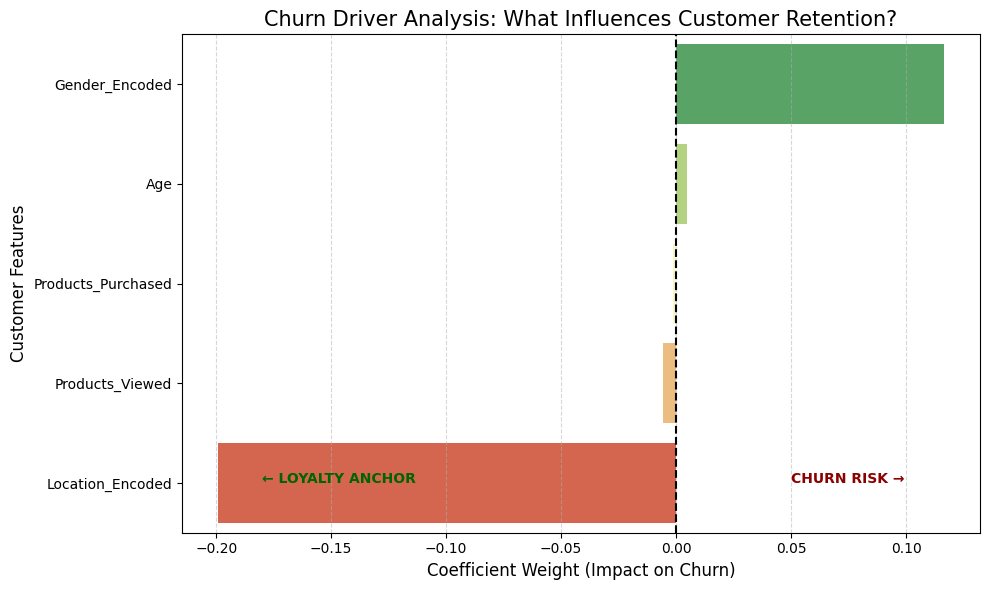

In [ ]:
# Using the exact weights from the model results
importance_data = {
    'Feature': ['Gender_Encoded', 'Age', 'Products_Purchased', 'Products_Viewed', 'Location_Encoded'],
    'Weight': [0.116399, 0.004884, -0.001499, -0.005612, -0.199031]
}

importance_df = pd.DataFrame(importance_data).sort_values(by='Weight', ascending=False)

# Create the plot
plt.figure(figsize=(10, 6))
# Using a Red-Yellow-Green palette to highlight Risk (Red) vs Loyalty (Green)
sns.barplot(x='Weight', y='Feature', data=importance_df, palette='RdYlGn_r')

plt.title('Churn Driver Analysis: What Influences Customer Retention?', fontsize=15)
plt.xlabel('Coefficient Weight (Impact on Churn)', fontsize=12)
plt.ylabel('Customer Features', fontsize=12)

# Add a vertical line at 0 to show the "Tipping Point"
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

# Add annotations to explain the sides
plt.text(0.05, 4, 'CHURN RISK →', color='darkred', fontweight='bold')
plt.text(-0.18, 4, '← LOYALTY ANCHOR', color='darkgreen', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('churn_drivers_chart.png')

In [ ]:
# --- FINAL EXPORT USING YOUR EXISTING DF ---

# 1. Export the current dataframe (with your existing encoded columns)
try:
    df.to_csv('bank_retention_final_PBI.csv', index=False)
    print("📁 SUCCESS: 'bank_retention_final_PBI.csv' created using your existing columns!")
except NameError:
    print("❌ Error: It seems the variable 'df' isn't recognized. Make sure the cell where you defined 'df' was run recently.")

# 2. Close the database connection safely
try:
    conn.close()
    print("✅ Database connection closed.")
except:
    print("ℹ️ Connection was already closed or not found.")

print("\n🏆 PROJECT COMPLETE. Ready for Power BI.")

📁 SUCCESS: 'bank_retention_final_PBI.csv' created using your existing columns!
✅ Database connection closed.

🏆 PROJECT COMPLETE. Ready for Power BI.


#**🏁 Project Conclusion: From Insights to Action**

Executive SummaryThis project successfully analyzed the churn dynamics of 1,000 retail banking customers. By bridging the gap between **Historical Data (SQL) and Predictive Modeling (Machine Learning)**, we have moved beyond simply knowing that customers leave, to understanding why they leave and who is next.

**📊 The "Data Story" Conclusion**

Through this analysis, we uncovered two critical behavioral paradoxes:
**1. The Gender Risk Gap:** While satisfaction levels were nearly identical between genders, our model identified Male customers as having a higher propensity to churn ($+0.116$ weight). This suggests that men in this dataset are "less tethered" and more likely to leave the bank even when they aren't actively complaining.

**2. The Urban Stickiness Paradox:** Our SQL analysis flagged Urban Seniors as the most dissatisfied group. However, the Machine Learning model revealed that Urban Location is the strongest anchor for retention ($-0.199$ weight). These customers are "High-Friction"—they are unhappy, but they stay because of higher switching costs or lack of alternatives.





##**💡 Strategic Recommendations**

**1. Proactive Retention for the "Flight Risk" Segment**

* **Target:** Male customers with low product counts.
* **Action:** Launch a "Multi-Product Loyalty" campaign. Since holding more products creates an anchor effect, offering bundled services (e.g., insurance or high-yield savings) specifically to the male demographic can reduce their likelihood of exit.

**2. Service Recovery for "Captive" Urban Centers**

* **Target:** Urban Senior populations.
* **Action:** Address the dissatisfaction before a competitor enters the market. Even though these customers are currently "sticky," their low satisfaction scores ($2.51$–$2.80$) make them prime targets for digital banks or new local competitors. Improving branch service for seniors is a defensive necessity.

**3. Digital UX Optimization**

**Target:** High-volume browsers.
**Action:** Fix the "Frustrated Browser" funnel. Customers with $40+$ views but only 1 purchase should be targeted with personalized offers or "Live Chat" assistance to convert their interest into product ownership, further securing their loyalty.

**🚀 Next Steps: Power BI Visualization**

The data has been cleaned, encoded, and exported as bank_retention_final.csv. The next phase of this project involves:

* **DAX Modeling:** Creating measures for Churn Rate % and Satisfaction Gap.

* **Dynamic Filtering:** Allowing stakeholders to toggle between Locations and Genders to see real-time risk scores.

* **Executive Dashboarding:** Visualizing the "Tug-of-War" between Churn Drivers and Loyalty Anchors.



**Cantwel Njeri| Project Completion: March 2026**